# IMU Axis Alignment Comparison + TCN Cross-Domain Evaluation

Samsung1 (source) ↔ Samsung2 (target) 의 IMU triceps (X/Y/Z) 축을 정렬하기 위해 세 가지 방법을 비교한다.

1. **Permutation + sign** — 축 순서 6 × 부호 8 = 48 후보 중 DTW 최소인 단일 (perm, sign)
2. **PCA-based** — 모든 운동 stack 후 source/target PCA basis 정렬 (`V_t.T @ V_s`)
3. **STranGAN** — adversarial 로 학습된 `SpatialTransformerBlock` (윈도우별 affine θ)

각 방법으로 정렬된 target 을 **동일한 TCN 분류기(source-only 학습)** 에 통과시켜 cross-domain 정확도를 비교한다.

데이터 가정: `notebook/` 기준 상위 `../data/samsung1.parquet`, `../data/samsung2_original.parquet`.

In [58]:
import os, time, math, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import spectral_norm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cuda


## 1. 데이터 로드

In [60]:
S1_PATH = '../data/samsung1.parquet'
S2_PATH = '../data/samsung2.parquet'

s1 = pd.read_parquet(S1_PATH)
s2 = pd.read_parquet(S2_PATH)

EX_LIST = sorted(set(s1['exercise'].unique()) & set(s2['exercise'].unique()))
print('samsung1:', s1.shape, '| samsung2:', s2.shape)
print('공통 운동:', EX_LIST)

samsung1: (16148132, 13) | samsung2: (26224560, 12)
공통 운동: ['barbellcurl', 'barbellrow', 'benchpress', 'bte', 'deadlift', 'dips', 'latpulldown', 'ohp', 'pullup', 'pushup']


## 2. 공통 유틸 — 슬라이싱 · z-score · DTW

In [61]:
SENSOR     = 'triceps'
WIN_LEN    = 200
WIN_STRIDE = 100
DURATION   = 8
START_FRAC = 0.25
S1_TIME    = 'timestamp'
S2_TIME    = 'TimeStamp'


def _to_seconds(series):
    try:
        t = pd.to_datetime(series)
        return (t - t.iloc[0]).dt.total_seconds().values
    except Exception:
        t = series.astype(float).values
        span = t[-1] - t[0]
        return (t - t[0]) / 1000.0 if span > 100 else (t - t[0])


def _slice_seg(df, ex, rep_idx, time_col,
               duration_sec=DURATION, start_frac=START_FRAC, default_hz=500):
    seg = df[df['exercise'] == ex]
    if 'rep' in seg.columns and seg['rep'].notna().any():
        reps = sorted(seg['rep'].dropna().unique())
        seg  = seg[seg['rep'] == reps[min(rep_idx, len(reps)-1)]]
    else:
        seg = seg.iloc[:int(duration_sec * 2000)]
    seg  = seg.copy().reset_index(drop=True)
    skip = int(len(seg) * start_frac)
    seg  = seg.iloc[skip:].reset_index(drop=True)
    n_cut = int(duration_sec * default_hz)
    if time_col and time_col in seg.columns and len(seg) > 1:
        t_s    = _to_seconds(seg[time_col])
        span_s = t_s[-1]
        if span_s > 0:
            n_cut = int(duration_sec * len(seg) / span_s)
    return seg.iloc[:min(len(seg), max(n_cut, 1))].reset_index(drop=True)


def _extract_mat(df, sensor, ex, rep_idx, time_col,
                 duration_sec=DURATION, start_frac=START_FRAC):
    seg = _slice_seg(df, ex, rep_idx, time_col, duration_sec, start_frac)
    arrs = [seg[f'{sensor}_{a}'].values if f'{sensor}_{a}' in seg.columns
            else np.zeros(len(seg)) for a in 'XYZ']
    return np.stack(arrs, axis=1).astype(np.float64)


def _zscore_mat(X):
    return (X - X.mean(0)) / (X.std(0) + 1e-8)


def _resample_mat(X, n):
    return X[np.linspace(0, len(X) - 1, n, dtype=int)]


def _dtw_raw(A, B, n_pts=200):
    """multivariate DTW; A, B 는 (T, 3) z-scored."""
    a, b = _resample_mat(A, n_pts), _resample_mat(B, n_pts)
    D = np.full((n_pts + 1, n_pts + 1), np.inf); D[0, 0] = 0.0
    for i in range(1, n_pts + 1):
        for j in range(1, n_pts + 1):
            D[i, j] = np.linalg.norm(a[i-1] - b[j-1]) + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return float(D[n_pts, n_pts])


def extract_s1(ex, r):    return _extract_mat(s1, SENSOR, ex, r, S1_TIME)
def extract_s2(ex, r=0):  return _extract_mat(s2, SENSOR, ex, r, S2_TIME)

print('utils ready.')

utils ready.


## 3. 축 정렬 방법론

### 3.1 Permutation + Sign brute-force

축 순서 6개 (XYZ, XZY, YXZ, YZX, ZXY, ZYX) × 부호 8개 (`±±±`) = **48 후보** 중,
모든 운동에 걸친 평균 DTW 가 가장 작아지는 단일 (perm, sign) 을 선택한다.
최종 변환은 `s2_z @ W_perm` (3×3 행렬).

In [62]:
PERMS = list(itertools.permutations([0, 1, 2]))     # 6
SIGNS = list(itertools.product([1, -1], repeat=3))  # 8
AXIS_NAME = ['X', 'Y', 'Z']


def perm_sign_W(perm, sign):
    """(s2_z @ W)[:, j] = sign[j] * s2_z[:, perm[j]]."""
    W = np.zeros((3, 3), dtype=np.float32)
    for out_axis, in_axis in enumerate(perm):
        W[in_axis, out_axis] = sign[out_axis]
    return W


def _label(perm, sign):
    return (''.join(AXIS_NAME[i] for i in perm),
            ''.join('+' if v == 1 else '-' for v in sign))


def rank_perm_sign(n_pts=200):
    """48 후보 모두의 운동 평균 DTW 를 계산해 ranking DataFrame 반환."""
    s1_z, s2_z = {}, {}
    for ex in EX_LIST:
        try:
            s1_z[ex] = _zscore_mat(extract_s1(ex, 0))
            s2_z[ex] = _zscore_mat(extract_s2(ex, 0))
        except Exception:
            pass

    records = []
    for perm in PERMS:
        for sign in SIGNS:
            W = perm_sign_W(perm, sign)
            dtws = [_dtw_raw(s1_z[ex], s2_z[ex] @ W, n_pts)
                    for ex in s1_z if ex in s2_z]
            if not dtws: continue
            p, s = _label(perm, sign)
            records.append({'perm': p, 'sign': s,
                            'mean_dtw': float(np.mean(dtws)),
                            '_perm': perm, '_sign': sign})
    df = pd.DataFrame(records).sort_values('mean_dtw').reset_index(drop=True)
    df.insert(0, 'rank', df.index + 1)
    return df


rank_df = rank_perm_sign()

print('=== Top 10 (perm, sign) by mean DTW ===')
print(rank_df[['rank', 'perm', 'sign', 'mean_dtw']].head(10).to_string(index=False))

print('\n=== YXZ 8개 sign 조합의 ranking ===')
print(rank_df[rank_df['perm'] == 'YXZ'][['rank', 'perm', 'sign', 'mean_dtw']]
      .to_string(index=False))

print('\n=== Identity (XYZ +++) baseline ===')
print(rank_df[(rank_df['perm'] == 'XYZ') & (rank_df['sign'] == '+++')]
      [['rank', 'perm', 'sign', 'mean_dtw']].to_string(index=False))

# 채택: 최상위 후보
top = rank_df.iloc[0]
best_perm, best_sign = top['_perm'], top['_sign']
W_perm = perm_sign_W(best_perm, best_sign)
print(f'\n채택: perm={top["perm"]}  sign={top["sign"]}  mean DTW={top["mean_dtw"]:.2f}')
print('W_perm =\n', W_perm)

=== Top 10 (perm, sign) by mean DTW ===
 rank perm sign   mean_dtw
    1  YXZ  --- 354.393927
    2  YXZ  --+ 357.545044
    3  XZY  +-- 367.187780
    4  XYZ  ++- 367.425588
    5  YZX  -++ 368.411234
    6  ZXY  +-- 369.161086
    7  YZX  --+ 372.223056
    8  XYZ  +++ 373.112694
    9  XYZ  --+ 373.245230
   10  XYZ  --- 374.048965

=== YXZ 8개 sign 조합의 ranking ===
 rank perm sign   mean_dtw
    1  YXZ  --- 354.393927
    2  YXZ  --+ 357.545044
   19  YXZ  ++- 392.104799
   20  YXZ  +++ 395.499288
   33  YXZ  -+- 405.852868
   36  YXZ  -++ 413.240670
   45  YXZ  +-- 419.663593
   48  YXZ  +-+ 422.941549

=== Identity (XYZ +++) baseline ===
 rank perm sign   mean_dtw
    8  XYZ  +++ 373.112694

채택: perm=YXZ  sign=---  mean DTW=354.39
W_perm =
 [[ 0. -1.  0.]
 [-1.  0.  0.]
 [ 0.  0. -1.]]


### 3.2 PCA-based

모든 운동 (rep 0) 데이터를 stack 한 뒤, source/target 각각 PCA 로 basis 추정 →
`W_pca = V_t.T @ V_s` 로 target basis 를 source basis 로 회전시킨다.
부호는 정렬 후 채널별 correlation 부호로 보정.

In [63]:
from sklearn.decomposition import PCA


def global_pca_W(n_pts=500):
    S, T = [], []
    for ex in EX_LIST:
        try:
            s1m, s2m = extract_s1(ex, 0), extract_s2(ex, 0)
        except Exception:
            continue
        if min(len(s1m), len(s2m)) < 20: continue
        n = min(len(s1m), len(s2m), n_pts)
        S.append(_resample_mat(_zscore_mat(s1m), n))
        T.append(_resample_mat(_zscore_mat(s2m), n))
    S = np.concatenate(S, 0); T = np.concatenate(T, 0)
    V_s = PCA(n_components=3).fit(S).components_
    V_t = PCA(n_components=3).fit(T).components_
    W   = (V_t.T @ V_s).astype(np.float32)

    # 채널별 sign fix (correlation 부호)
    aligned = T @ W
    for j in range(3):
        if np.corrcoef(S[:, j], aligned[:, j])[0, 1] < 0:
            W[:, j] *= -1
    return W


W_pca = global_pca_W()
print('W_pca =\n', np.round(W_pca, 3))

W_pca =
 [[-0.156 -0.708  0.689]
 [-0.971 -0.016 -0.237]
 [ 0.179 -0.706 -0.685]]


### 3.3 STranGAN (deep learning)

`SpatialTransformerBlock` 이 윈도우마다 affine θ ∈ ℝ^(4×3) 을 회귀한다.
초기값은 identity (회전 0, 평행이동 0). BCE adversarial + SmoothL1 reconstruction 으로 학습.

In [64]:
class MinibatchDiscrimination1d(nn.Module):
    def __init__(self, in_features, out_features, kernel_dims=16):
        super().__init__()
        self.out_features = out_features
        self.kernel_dims  = kernel_dims
        self.T = nn.Parameter(torch.randn(in_features, out_features * kernel_dims) * 0.1)

    def forward(self, x):
        M = (x @ self.T).view(-1, self.out_features, self.kernel_dims)
        l1 = (M.unsqueeze(0) - M.unsqueeze(1)).abs().sum(-1)
        feats = torch.exp(-l1).sum(1)
        return torch.cat([x, feats], dim=1)


class LocalizationNet(nn.Module):
    def __init__(self, n_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(9, 1), stride=(2, 1)), nn.SELU(),
            nn.MaxPool2d(kernel_size=(2, 1)),
            nn.Conv2d(32, 64, kernel_size=(9, 1), stride=(2, 1)), nn.SELU(),
            nn.AdaptiveAvgPool2d((4, n_channels)),
        )
        self.flat_dim = 64 * 4 * n_channels

    def forward(self, x):
        return self.net(x).flatten(1)


class SpatialTransformerBlock(nn.Module):
    def __init__(self, n_channels=3):
        super().__init__()
        self.loc = LocalizationNet(n_channels)
        self.fc_loc = nn.Sequential(
            nn.Linear(self.loc.flat_dim, 128), nn.SELU(),
            nn.Linear(128, 64),                nn.SELU(),
            nn.Linear(64, 12),
        )
        self.fc_loc[-1].weight.data.zero_()
        self.fc_loc[-1].bias.data.copy_(torch.tensor(
            [1,0,0, 0,1,0, 0,0,1, 0,0,0], dtype=torch.float32))

    def forward(self, x):
        x_btc = x.transpose(1, 2)
        feat  = self.loc(x_btc.unsqueeze(1))
        theta = self.fc_loc(feat).view(-1, 4, 3)
        ones  = torch.ones(x_btc.size(0), x_btc.size(1), 1,
                           device=x.device, dtype=x.dtype)
        y     = torch.matmul(torch.cat([x_btc, ones], dim=2), theta)
        return y.transpose(1, 2), theta


class Discriminator(nn.Module):
    def __init__(self, n_channels=3):
        super().__init__()
        self.conv = nn.Sequential(
            spectral_norm(nn.Conv1d(n_channels, 64, 9, stride=2)), nn.SELU(),
            spectral_norm(nn.Conv1d(64, 128, 9, stride=2)),       nn.SELU(),
            spectral_norm(nn.Conv1d(128, 256, 9, stride=2)),      nn.SELU(),
            nn.AdaptiveAvgPool1d(4),
        )
        self.fc  = spectral_norm(nn.Linear(256 * 4, 64))
        self.mbd = MinibatchDiscrimination1d(64, 32, kernel_dims=16)
        self.out = spectral_norm(nn.Linear(64 + 32, 1))

    def forward(self, x):
        h = self.conv(x).flatten(1)
        h = F.selu(self.fc(h))
        h = self.mbd(h)
        return self.out(h)

print('STranGAN modules defined.')

STranGAN modules defined.


src/tgt windows: (5950, 3, 200) (1190, 3, 200)
ep   1/30  D=0.2400  G_adv=3.2123  G_rec=0.1124  (0.7s)
ep   5/30  D=0.1053  G_adv=5.1296  G_rec=0.1697  (3.5s)
ep  10/30  D=0.0591  G_adv=6.8283  G_rec=0.1164  (7.0s)
ep  15/30  D=0.1366  G_adv=5.2146  G_rec=0.1160  (10.5s)
ep  20/30  D=0.0555  G_adv=7.1296  G_rec=0.0837  (14.0s)
ep  25/30  D=0.0802  G_adv=6.1725  G_rec=0.0970  (17.5s)
ep  30/30  D=0.1505  G_adv=4.9418  G_rec=0.0919  (21.0s)


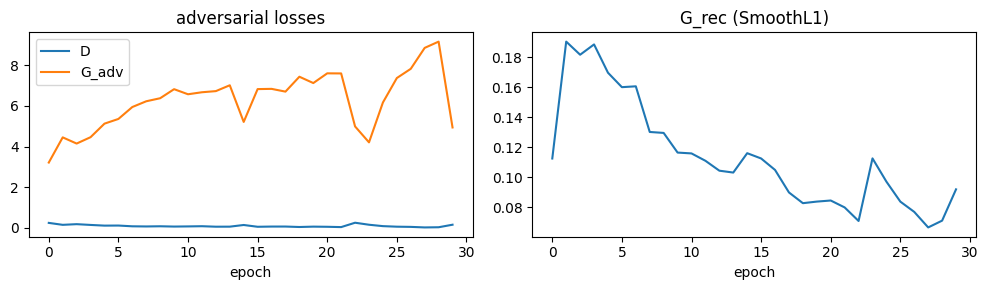

In [65]:
def build_unlabeled_windows(df, time_col, n_reps,
                            win_len=WIN_LEN, win_stride=WIN_STRIDE):
    out = []
    for ex in EX_LIST:
        for r in range(n_reps):
            try:
                M = _extract_mat(df, SENSOR, ex, r, time_col)
            except Exception:
                continue
            if len(M) < win_len: continue
            Z = _zscore_mat(M)
            for s in range(0, len(Z) - win_len + 1, win_stride):
                out.append(Z[s:s+win_len].T)
    return (np.asarray(out, dtype=np.float32)
            if out else np.empty((0, 3, win_len), np.float32))


class TensorDS(Dataset):
    def __init__(self, X): self.X = torch.from_numpy(X)
    def __len__(self):     return len(self.X)
    def __getitem__(self, i): return self.X[i]


def _cycle(loader):
    while True:
        for b in loader: yield b


def train_strangan(epochs=30, gamma_rec=5.0, lr=2e-4, batch=64):
    X_src = build_unlabeled_windows(s1, S1_TIME, n_reps=5)
    X_tgt = build_unlabeled_windows(s2, S2_TIME, n_reps=1)
    print('src/tgt windows:', X_src.shape, X_tgt.shape)

    src_loader = DataLoader(TensorDS(X_src), batch_size=batch, shuffle=True, drop_last=True)
    tgt_loader = DataLoader(TensorDS(X_tgt), batch_size=batch, shuffle=True, drop_last=True)

    G = SpatialTransformerBlock().to(DEVICE)
    D = Discriminator().to(DEVICE)
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    adv   = nn.BCEWithLogitsLoss(); rec = nn.SmoothL1Loss()

    hist  = {'D': [], 'G_adv': [], 'G_rec': []}
    iters = max(len(src_loader), len(tgt_loader))
    src_it, tgt_it = _cycle(src_loader), _cycle(tgt_loader)

    t0 = time.time()
    for ep in range(1, epochs + 1):
        d_sum = g_adv_sum = g_rec_sum = 0.0; nb = 0
        for _ in range(iters):
            x_s = next(src_it).to(DEVICE); x_t = next(tgt_it).to(DEVICE)
            B = min(x_s.size(0), x_t.size(0))
            x_s, x_t = x_s[:B], x_t[:B]
            ones = torch.ones (B, 1, device=DEVICE)
            zers = torch.zeros(B, 1, device=DEVICE)

            with torch.no_grad():
                x_tf, _ = G(x_t)
            loss_D = 0.5 * (adv(D(x_s), ones) + adv(D(x_tf), zers))
            opt_D.zero_grad(); loss_D.backward(); opt_D.step()

            x_tg, _ = G(x_t); x_sg, _ = G(x_s)
            l_adv  = adv(D(x_tg), ones)
            l_rec  = rec(x_sg, x_s)
            loss_G = l_adv + gamma_rec * l_rec
            opt_G.zero_grad(); loss_G.backward(); opt_G.step()

            d_sum     += loss_D.item()
            g_adv_sum += l_adv.item()
            g_rec_sum += l_rec.item(); nb += 1

        hist['D'].append(d_sum/nb); hist['G_adv'].append(g_adv_sum/nb); hist['G_rec'].append(g_rec_sum/nb)
        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(f'ep {ep:>3}/{epochs}  D={hist["D"][-1]:.4f}  G_adv={hist["G_adv"][-1]:.4f}  '
                  f'G_rec={hist["G_rec"][-1]:.4f}  ({time.time()-t0:.1f}s)')

    return G, hist


@torch.no_grad()
def apply_G_to_signal(M, G, win_len=WIN_LEN, win_stride=WIN_STRIDE):
    """(N, 3) → z-score → 슬라이딩 G → overlap-average → (N, 3)."""
    Z = _zscore_mat(M).astype(np.float32)
    N = len(Z)
    if N < win_len: return Z
    G.eval()
    out = np.zeros_like(Z); cnt = np.zeros(N, dtype=np.float32)
    starts = list(range(0, N - win_len + 1, win_stride))
    if starts[-1] != N - win_len: starts.append(N - win_len)
    for s in starts:
        w = torch.from_numpy(Z[s:s+win_len].T).unsqueeze(0).to(DEVICE)
        y, _ = G(w)
        y = y.squeeze(0).cpu().numpy().T
        out[s:s+win_len] += y; cnt[s:s+win_len] += 1.0
    return out / cnt[:, None]


G_strangan, hist_strangan = train_strangan(epochs=30)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(hist_strangan['D'], label='D'); ax[0].plot(hist_strangan['G_adv'], label='G_adv')
ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].set_title('adversarial losses')
ax[1].plot(hist_strangan['G_rec']); ax[1].set_xlabel('epoch'); ax[1].set_title('G_rec (SmoothL1)')
plt.tight_layout(); plt.show()

## 4. DTW 비교 (raw vs perm vs pca vs strangan)

   exercise    raw   perm    pca  strangan
barbellcurl 407.21 358.20 345.13    632.54
 barbellrow 386.31 388.74 350.87    855.73
 benchpress 400.86 306.39 330.76   1248.11
        bte 321.81 411.38 358.86    475.31
   deadlift 387.94 374.52 403.75    525.53
       dips 335.12 326.42 382.80    864.04
latpulldown 356.26 327.96 327.72    763.34
        ohp 501.42 337.24 342.92    570.83
     pullup 356.66 356.68 392.05    667.85
     pushup 277.54 356.40 332.86    337.80
       MEAN 373.11 354.39 356.77    694.11


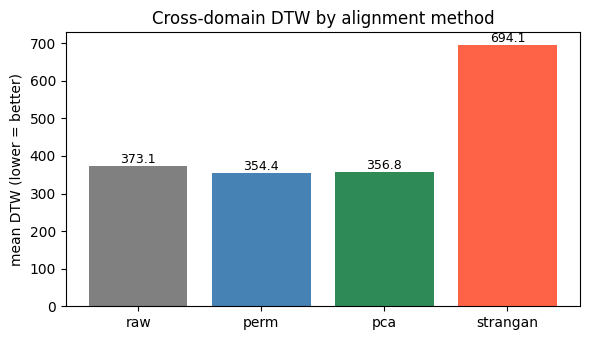

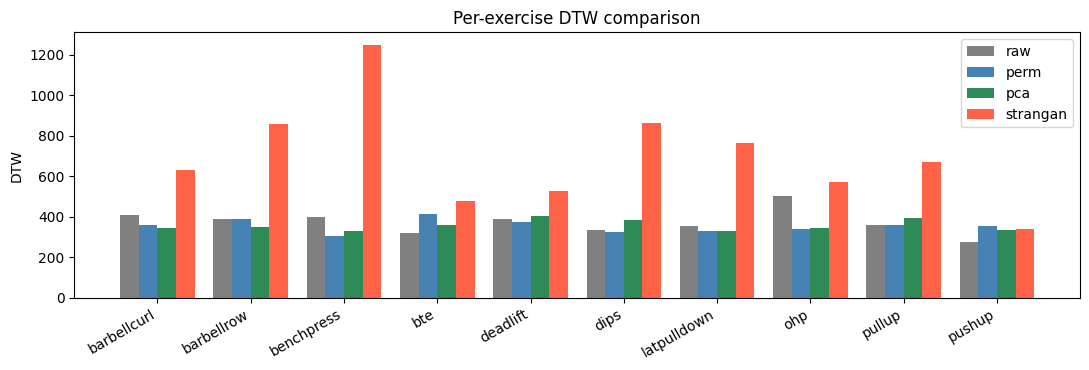

In [66]:
ALIGN_METHODS = {
    'raw':      lambda M: _zscore_mat(M).astype(np.float32),
    'perm':     lambda M: (_zscore_mat(M) @ W_perm).astype(np.float32),
    'pca':      lambda M: (_zscore_mat(M) @ W_pca ).astype(np.float32),
    'strangan': lambda M: apply_G_to_signal(M, G_strangan).astype(np.float32),
}
METHOD_ORDER = list(ALIGN_METHODS.keys())
METHOD_COLOR = {'raw': 'gray', 'perm': 'steelblue', 'pca': 'seagreen', 'strangan': 'tomato'}


def dtw_comparison(n_reps=3, n_pts=200):
    rows = []
    for ex in EX_LIST:
        try:
            s2m = extract_s2(ex, 0)
        except Exception:
            continue
        if len(s2m) < 20: continue
        aligned = {n: fn(s2m) for n, fn in ALIGN_METHODS.items()}

        per_method = {n: [] for n in ALIGN_METHODS}
        for r in range(n_reps):
            try:
                s1m = extract_s1(ex, r)
            except Exception:
                continue
            if len(s1m) < 20: continue
            s1z = _zscore_mat(s1m)
            for n, sig in aligned.items():
                per_method[n].append(_dtw_raw(s1z, sig, n_pts))
        if all(per_method[n] for n in ALIGN_METHODS):
            rows.append({'exercise': ex,
                         **{n: float(np.mean(per_method[n])) for n in ALIGN_METHODS}})
    df = pd.DataFrame(rows)
    df.loc[len(df)] = {'exercise': 'MEAN',
                       **{n: df[n].mean() for n in ALIGN_METHODS}}
    return df


dtw_df = dtw_comparison()
print(dtw_df.round(2).to_string(index=False))

# mean DTW bar chart
means = dtw_df.iloc[-1].drop('exercise').astype(float)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(means.index, means.values, color=[METHOD_COLOR[n] for n in means.index])
ax.set_ylabel('mean DTW (lower = better)')
ax.set_title('Cross-domain DTW by alignment method')
for i, v in enumerate(means.values):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

# per-exercise grouped bar chart
ex_only = dtw_df.iloc[:-1]
x = np.arange(len(ex_only))
w = 0.20
fig, ax = plt.subplots(figsize=(11, 3.8))
for i, n in enumerate(METHOD_ORDER):
    ax.bar(x + (i - 1.5) * w, ex_only[n], width=w, color=METHOD_COLOR[n], label=n)
ax.set_xticks(x); ax.set_xticklabels(ex_only['exercise'], rotation=30, ha='right')
ax.set_ylabel('DTW'); ax.legend(loc='upper right')
ax.set_title('Per-exercise DTW comparison')
plt.tight_layout(); plt.show()

## 5. 정렬 후 파형 시각화

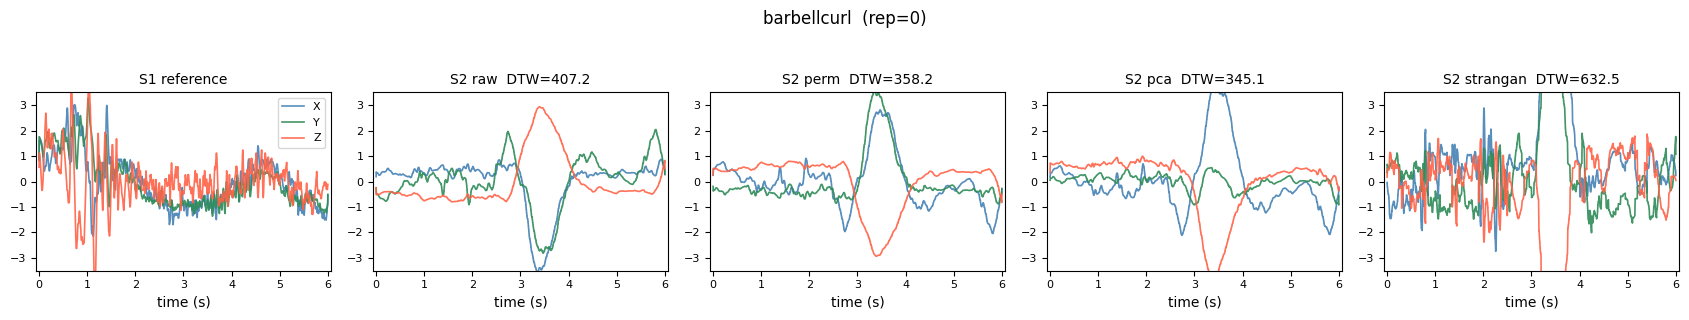

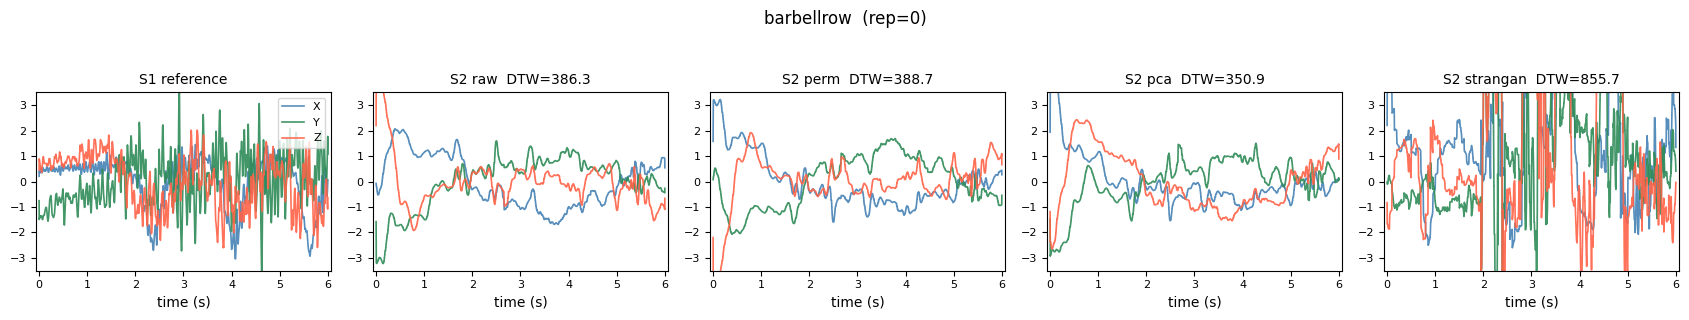

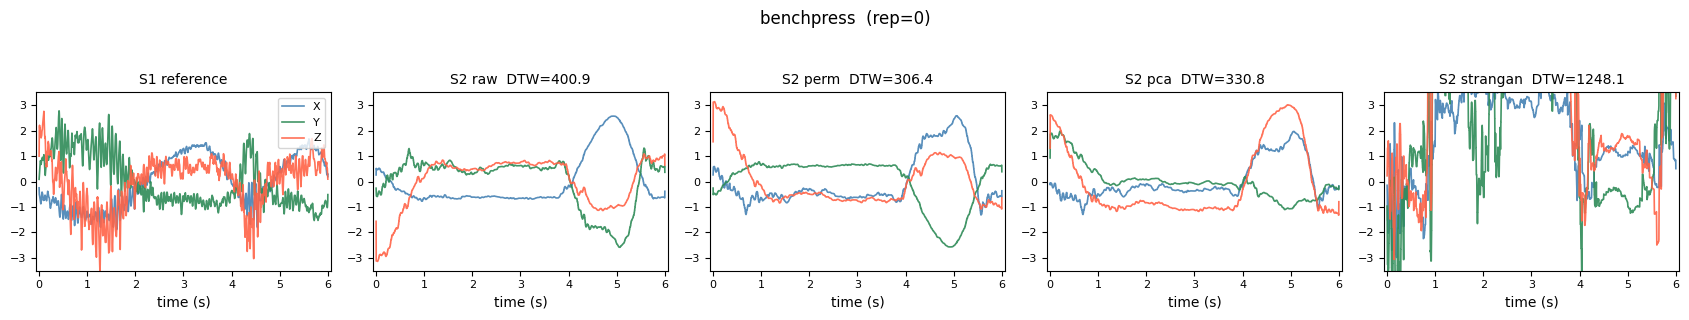

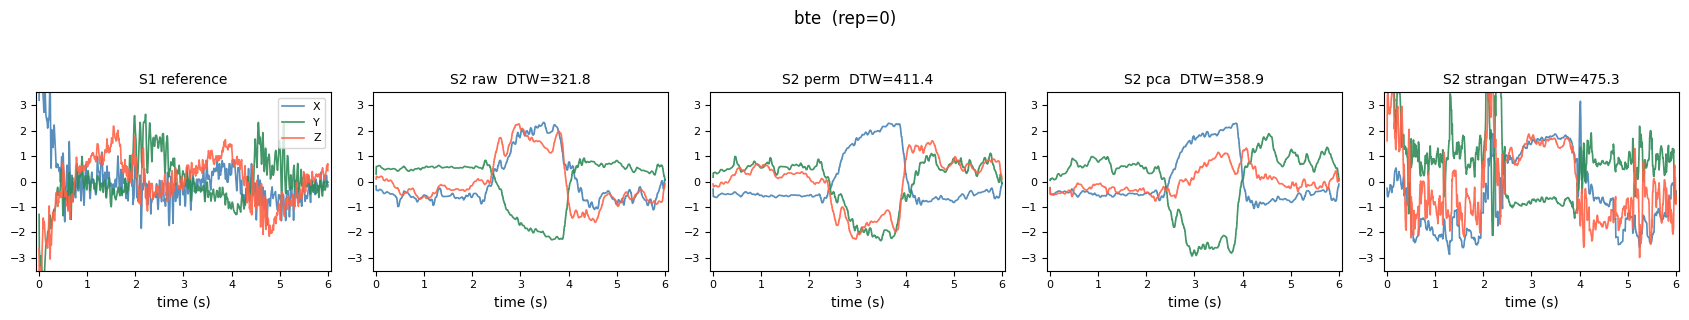

In [67]:
def _smooth(sig, w=10):
    if w <= 1 or len(sig) < w: return sig
    return np.convolve(sig, np.ones(w)/w, mode='same')


def plot_alignment(ex_list, rep_idx=0, smooth_w=10, n_pts=200):
    xyz_c = ['steelblue', 'seagreen', 'tomato']; xyz_l = ['X', 'Y', 'Z']
    for ex in ex_list:
        try:
            s1m = extract_s1(ex, rep_idx)
            s2m = extract_s2(ex, 0)
        except Exception:
            continue
        if min(len(s1m), len(s2m)) < 20: continue
        s1z = _zscore_mat(s1m)
        aligned = {n: ALIGN_METHODS[n](s2m) for n in METHOD_ORDER}
        dtws    = {n: _dtw_raw(s1z, aligned[n], n_pts) for n in METHOD_ORDER}

        panels = [('S1 reference', s1z)] + \
                 [(f'S2 {n}  DTW={dtws[n]:.1f}', aligned[n]) for n in METHOD_ORDER]
        fig, axes = plt.subplots(1, len(panels), figsize=(3.4 * len(panels), 3.0))
        for ax, (title, mat) in zip(axes, panels):
            x = np.linspace(0, DURATION * (1 - START_FRAC), len(mat))
            for k in range(3):
                ax.plot(x, _smooth(mat[:, k], smooth_w),
                        color=xyz_c[k], lw=1.2, alpha=0.9, label=xyz_l[k])
            ax.set_title(title, fontsize=10)
            ax.set_xlabel('time (s)'); ax.tick_params(labelsize=8)
            ax.set_ylim(-3.5, 3.5); ax.margins(x=0.01)
        axes[0].legend(fontsize=8, loc='upper right')
        fig.suptitle(f'{ex}  (rep={rep_idx})', fontsize=12, y=1.05)
        plt.tight_layout(); plt.show()


plot_alignment(EX_LIST[:4])

## 6. TCN cross-domain 분류 비교

동일한 TCN 분류기를 **source(s1) 만으로 10 epoch 학습**하고,
각 축 정렬 방법으로 변환한 target 에서 정확도를 평가한다.

src train/val: (4760, 3, 200) (1190, 3, 200)
  target[      raw]: (1190, 3, 200)
  target[     perm]: (1190, 3, 200)
  target[      pca]: (1190, 3, 200)
  target[ strangan]: (1190, 3, 200)
ep  1/10  loss=1.4559  src_val=0.593  tgt_raw=0.150  tgt_perm=0.091  tgt_pca=0.109  tgt_strangan=0.085  (0.6s)
ep  2/10  loss=1.0390  src_val=0.642  tgt_raw=0.179  tgt_perm=0.149  tgt_pca=0.107  tgt_strangan=0.068  (1.2s)
ep  3/10  loss=0.9264  src_val=0.739  tgt_raw=0.129  tgt_perm=0.125  tgt_pca=0.122  tgt_strangan=0.082  (1.8s)
ep  4/10  loss=0.8152  src_val=0.739  tgt_raw=0.147  tgt_perm=0.120  tgt_pca=0.092  tgt_strangan=0.071  (2.4s)
ep  5/10  loss=0.7108  src_val=0.724  tgt_raw=0.157  tgt_perm=0.126  tgt_pca=0.128  tgt_strangan=0.071  (3.0s)
ep  6/10  loss=0.6601  src_val=0.808  tgt_raw=0.184  tgt_perm=0.140  tgt_pca=0.161  tgt_strangan=0.091  (3.6s)
ep  7/10  loss=0.5812  src_val=0.863  tgt_raw=0.177  tgt_perm=0.140  tgt_pca=0.166  tgt_strangan=0.084  (4.2s)
ep  8/10  loss=0.5143  src_val=0.8

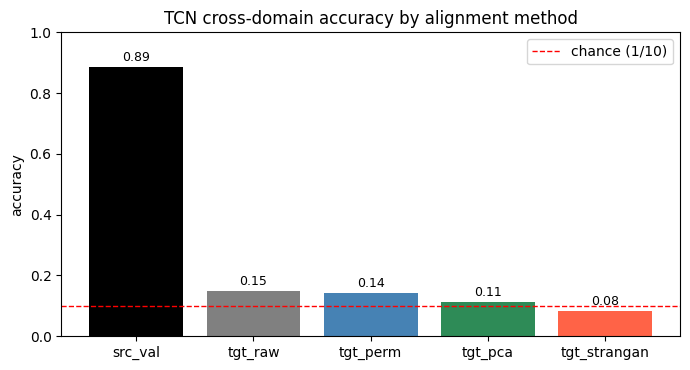

In [68]:
from sklearn.model_selection import train_test_split


def build_labeled_windows(df, time_col, n_reps, align_fn,
                          win_len=WIN_LEN, win_stride=WIN_STRIDE):
    label_map = {ex: i for i, ex in enumerate(EX_LIST)}
    X, y = [], []
    for ex in EX_LIST:
        for r in range(n_reps):
            try:
                M = _extract_mat(df, SENSOR, ex, r, time_col)
            except Exception:
                continue
            if len(M) < win_len: continue
            Z = align_fn(M)
            for s in range(0, len(Z) - win_len + 1, win_stride):
                X.append(Z[s:s+win_len].T)
                y.append(label_map[ex])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.int64)


class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=5, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch,  out_ch, kernel, padding=pad, dilation=dilation)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel, padding=pad, dilation=dilation)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.down  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        L = x.size(-1)
        h = F.relu(self.bn1(self.conv1(x)[:, :, :L]))
        h = self.drop(h)
        h = self.bn2(self.conv2(h)[:, :, :L])
        return F.relu(h + self.down(x))


class TCN(nn.Module):
    def __init__(self, in_ch=3, n_classes=10, hid=64, levels=4, kernel=5):
        super().__init__()
        self.net  = nn.Sequential(*[
            TCNBlock(in_ch if i == 0 else hid, hid, kernel, dilation=2**i)
            for i in range(levels)])
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(hid, n_classes)

    def forward(self, x):
        return self.fc(self.pool(self.net(x)).squeeze(-1))


class LabeledDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X); self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


@torch.no_grad()
def eval_acc(model, loader):
    model.eval(); correct = total = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred = model(xb).argmax(-1)
        correct += (pred == yb).sum().item(); total += yb.numel()
    return correct / max(total, 1)


# === source 학습 데이터 (z-score만, 정렬 없음) ===
X_src, y_src = build_labeled_windows(s1, S1_TIME, n_reps=5, align_fn=ALIGN_METHODS['raw'])
X_tr, X_va, y_tr, y_va = train_test_split(
    X_src, y_src, test_size=0.2, stratify=y_src, random_state=SEED)
print('src train/val:', X_tr.shape, X_va.shape)

tr_loader = DataLoader(LabeledDS(X_tr, y_tr), batch_size=64,  shuffle=True, drop_last=True)
va_loader = DataLoader(LabeledDS(X_va, y_va), batch_size=128)

# === target loaders: 정렬 방법별 ===
target_loaders = {}
for name, fn in ALIGN_METHODS.items():
    X_tgt, y_tgt = build_labeled_windows(s2, S2_TIME, n_reps=1, align_fn=fn)
    target_loaders[name] = DataLoader(LabeledDS(X_tgt, y_tgt), batch_size=128)
    print(f'  target[{name:>9}]: {X_tgt.shape}')


# === TCN 학습 (source-only, 10 epochs) ===
torch.manual_seed(SEED)
model = TCN(in_ch=3, n_classes=len(EX_LIST)).to(DEVICE)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
crit  = nn.CrossEntropyLoss()

EPOCHS_TCN = 10
t0 = time.time()
for ep in range(1, EPOCHS_TCN + 1):
    model.train(); tot = 0.0; nb = 0
    for xb, yb in tr_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = crit(model(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item(); nb += 1
    accs = {n: eval_acc(model, ld) for n, ld in target_loaders.items()}
    print(f'ep {ep:>2}/{EPOCHS_TCN}  loss={tot/nb:.4f}  src_val={eval_acc(model, va_loader):.3f}  '
          + '  '.join(f'tgt_{n}={a:.3f}' for n, a in accs.items())
          + f'  ({time.time()-t0:.1f}s)')


# === 최종 정확도 요약 ===
final_src_val = eval_acc(model, va_loader)
final_accs    = {n: eval_acc(model, ld) for n, ld in target_loaders.items()}

print('\n=== 최종 정확도 ===')
print(f'  source val            : {final_src_val:.3f}')
for n, a in final_accs.items():
    print(f'  target[{n:>9}]      : {a:.3f}')

fig, ax = plt.subplots(figsize=(7, 3.8))
labels = ['src_val'] + [f'tgt_{n}' for n in METHOD_ORDER]
values = [final_src_val] + [final_accs[n] for n in METHOD_ORDER]
colors = ['black'] + [METHOD_COLOR[n] for n in METHOD_ORDER]
ax.bar(labels, values, color=colors)
ax.axhline(1/len(EX_LIST), color='red', lw=1, ls='--', label=f'chance (1/{len(EX_LIST)})')
ax.set_ylabel('accuracy'); ax.set_ylim(0, 1)
ax.set_title('TCN cross-domain accuracy by alignment method')
for i, v in enumerate(values):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

## 7. 48 후보 전수 평가 — TCN target accuracy ranking

DTW 가 분류 성능을 예측 못 하는 걸 확인했으니, 학습된 TCN 으로 **48개 (perm, sign) 후보를 target 변환에 적용한 뒤 정확도 ranking** 을 매긴다.
또한 DTW ranking 과 accuracy ranking 의 산점도로 둘의 (비)상관성도 확인.

=== Top 10 by TCN target accuracy ===
 rank perm sign  accuracy  dtw_rank  mean_dtw
    1  ZYX  +++    0.2000        23  396.6523
    2  ZXY  +--    0.1790        13  378.8915
    3  XZY  -+-    0.1697        15  388.5147
    4  YZX  +-+    0.1655        34  408.2684
    5  YZX  +++    0.1622        41  416.0548
    6  YXZ  ++-    0.1588         4  367.4256
    7  YXZ  +++    0.1471         8  373.1127
    8  XYZ  ---    0.1462         1  354.3939
    9  ZYX  -++    0.1445        28  400.9682
   10  XZY  +--    0.1353        26  400.8990

=== YXZ 8개 sign 조합 (accuracy 순위) ===
 rank perm sign  accuracy  dtw_rank  mean_dtw
    6  YXZ  ++-    0.1588         4  367.4256
    7  YXZ  +++    0.1471         8  373.1127
   14  YXZ  +--    0.1294        35  411.9405
   31  YXZ  +-+    0.0874        40  414.3704
   33  YXZ  --+    0.0849         9  373.2452
   44  YXZ  ---    0.0563        10  374.0490
   47  YXZ  -++    0.0361        46  420.6989
   48  YXZ  -+-    0.0277        39  414.2849

===

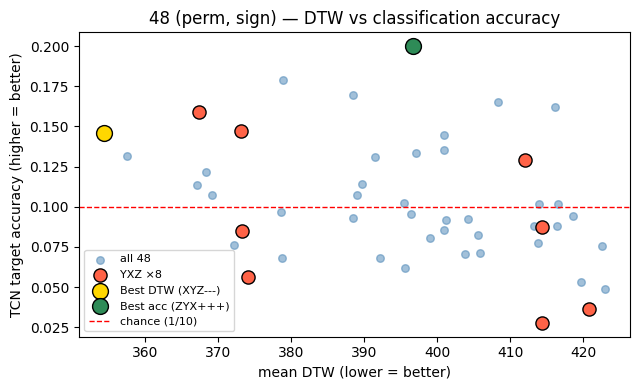


Spearman ρ(DTW, accuracy) = -0.380  (p=0.0077)
  음의 상관이 강하면 DTW 가 분류 성능을 잘 예측한다는 뜻.


In [56]:
# 학습된 model 을 그대로 사용 (재학습 없음). target 변환만 48가지로 바꿔가며 정확도 측정.
acc_rows = []
for perm in PERMS:
    for sign in SIGNS:
        W = perm_sign_W(perm, sign)
        align_fn   = lambda M, W=W: (_zscore_mat(M) @ W).astype(np.float32)
        X_t, y_t   = build_labeled_windows(s2, S2_TIME, n_reps=1, align_fn=align_fn)
        ld         = DataLoader(LabeledDS(X_t, y_t), batch_size=128)
        acc        = eval_acc(model, ld)
        p, s       = _label(perm, sign)
        acc_rows.append({'perm': p, 'sign': s, 'accuracy': acc})

acc_df = pd.DataFrame(acc_rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
acc_df.insert(0, 'rank', acc_df.index + 1)

# DTW ranking 과 mean_dtw 합치기
dtw_map = {(r['perm'], r['sign']): (r['rank'], r['mean_dtw']) for _, r in rank_df.iterrows()}
acc_df['dtw_rank'] = [dtw_map[(p, s)][0] for p, s in zip(acc_df['perm'], acc_df['sign'])]
acc_df['mean_dtw'] = [dtw_map[(p, s)][1] for p, s in zip(acc_df['perm'], acc_df['sign'])]

print('=== Top 10 by TCN target accuracy ===')
print(acc_df.head(10).round(4).to_string(index=False))

print('\n=== YXZ 8개 sign 조합 (accuracy 순위) ===')
print(acc_df[acc_df['perm'] == 'YXZ'].round(4).to_string(index=False))

print('\n=== DTW Top 5 가 accuracy ranking 에서 어디 있나 ===')
for _, r in rank_df.head(5).iterrows():
    row = acc_df[(acc_df['perm'] == r['perm']) & (acc_df['sign'] == r['sign'])].iloc[0]
    print(f"  {r['perm']}{r['sign']}  dtw_rank={int(r['rank']):>2}  "
          f"acc_rank={int(row['rank']):>2}  acc={row['accuracy']:.3f}")


# === DTW vs accuracy 산점도 ===
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(acc_df['mean_dtw'], acc_df['accuracy'],
           c='steelblue', alpha=0.5, s=30, label='all 48')

yxz = acc_df[acc_df['perm'] == 'YXZ']
ax.scatter(yxz['mean_dtw'], yxz['accuracy'],
           c='tomato', s=90, label='YXZ ×8', zorder=5, edgecolors='black')

best_dtw = acc_df.loc[acc_df['mean_dtw'].idxmin()]
ax.scatter([best_dtw['mean_dtw']], [best_dtw['accuracy']],
           c='gold', s=130, label=f"Best DTW ({best_dtw['perm']}{best_dtw['sign']})",
           zorder=6, edgecolors='black')

best_acc = acc_df.iloc[0]
ax.scatter([best_acc['mean_dtw']], [best_acc['accuracy']],
           c='seagreen', s=130, label=f"Best acc ({best_acc['perm']}{best_acc['sign']})",
           zorder=6, edgecolors='black')

ax.axhline(1/len(EX_LIST), color='red', lw=1, ls='--', label=f'chance (1/{len(EX_LIST)})')
ax.set_xlabel('mean DTW (lower = better)')
ax.set_ylabel('TCN target accuracy (higher = better)')
ax.set_title('48 (perm, sign) — DTW vs classification accuracy')
ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()

# Spearman 상관계수 — DTW ranking 과 accuracy ranking 사이
from scipy.stats import spearmanr
rho, pval = spearmanr(acc_df['mean_dtw'], acc_df['accuracy'])
print(f'\nSpearman ρ(DTW, accuracy) = {rho:+.3f}  (p={pval:.3g})')
print('  음의 상관이 강하면 DTW 가 분류 성능을 잘 예측한다는 뜻.')

## 8. STB → TCN + DANN end-to-end (1번 안)

STB 를 TCN 앞에 놓고 **source CE + 도메인 적대 손실** 로 joint 학습.

- **STB**: `SpatialTransformerBlock` (윈도우별 affine θ, identity 초기화)
- **GRL**: Gradient Reversal Layer — STB 가 도메인 구분을 *방해* 하는 방향으로 학습
- **D**: 도메인 판별기 (입력 = STB 출력 신호)
- **TCN**: 분류기, source CE 로만 학습

λ (도메인 손실 가중) 은 DANN paper schedule `2/(1+exp(-10·p)) - 1` (epoch 진행에 따라 0→1).
**target label 은 사용 안 함** (순수 UDA). 모니터링용 target accuracy 만 매 epoch 출력.

ep   1/30  λ=0.16  cls=1.431  dom=0.623  src_val=0.635  tgt=0.137  (0.8s)
ep   2/30  λ=0.32  cls=1.029  dom=0.551  src_val=0.672  tgt=0.086  (1.6s)
ep   3/30  λ=0.46  cls=0.920  dom=0.535  src_val=0.650  tgt=0.109  (2.3s)
ep   4/30  λ=0.58  cls=0.834  dom=0.505  src_val=0.719  tgt=0.118  (3.1s)
ep   5/30  λ=0.68  cls=0.777  dom=0.511  src_val=0.737  tgt=0.116  (3.9s)
ep   6/30  λ=0.76  cls=0.715  dom=0.524  src_val=0.758  tgt=0.082  (4.7s)
ep   7/30  λ=0.82  cls=0.617  dom=0.505  src_val=0.764  tgt=0.098  (5.5s)
ep   8/30  λ=0.87  cls=0.574  dom=0.528  src_val=0.777  tgt=0.117  (6.3s)
ep   9/30  λ=0.90  cls=0.532  dom=0.519  src_val=0.781  tgt=0.077  (7.0s)
ep  10/30  λ=0.93  cls=0.484  dom=0.557  src_val=0.799  tgt=0.097  (7.8s)
ep  11/30  λ=0.95  cls=0.482  dom=0.569  src_val=0.857  tgt=0.131  (8.6s)
ep  12/30  λ=0.96  cls=0.454  dom=0.512  src_val=0.811  tgt=0.100  (9.4s)
ep  13/30  λ=0.97  cls=0.379  dom=0.519  src_val=0.857  tgt=0.093  (10.2s)
ep  14/30  λ=0.98  cls=0.394  dom=0.5

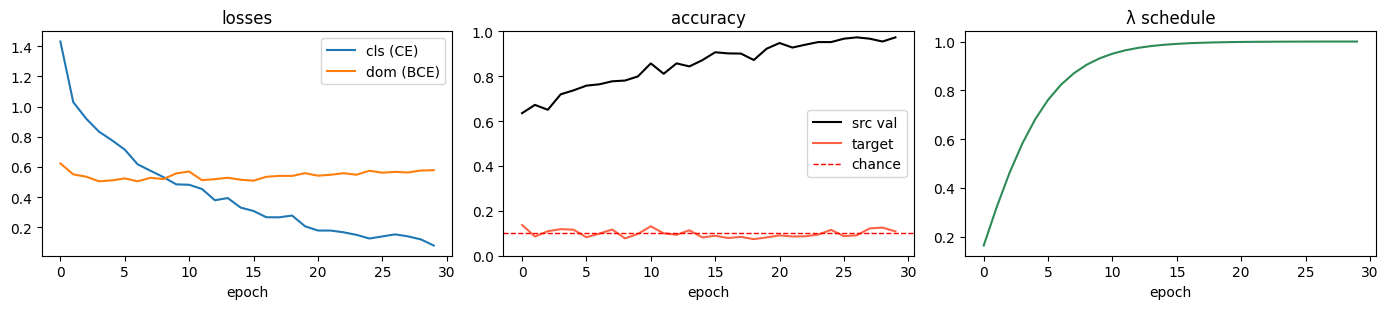


=== Target accuracy 비교 ===
  Section 6  TCN (no STB, raw)        : 0.103
  Section 6  TCN + permutation align  : 0.146
  Section 6  TCN + PCA align          : 0.103
  Section 6  TCN + STranGAN (frozen)  : 0.105
  Section 8  STB → TCN + DANN (joint) : 0.108  ← NEW

학습된 STB 의 mean θ (target 기준, 4x3):
[[ 4.509  0.546  0.22 ]
 [-0.848  0.488 -0.321]
 [-1.111 -1.472  2.736]
 [-0.62  -2.153  3.264]]


In [57]:
# === Gradient Reversal Layer ===
class _GRLFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad):
        return -ctx.lambda_ * grad, None


def grl(x, lambda_):
    return _GRLFn.apply(x, lambda_)


# === Domain Discriminator (lightweight, no spectral norm) ===
class DomainDiscriminator(nn.Module):
    def __init__(self, n_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 64, 9, stride=2), nn.ReLU(),
            nn.Conv1d(64, 128, 9, stride=2),       nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


# === Combined STB → TCN + DANN ===
class STB_TCN_DANN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.stb  = SpatialTransformerBlock(n_channels=3)
        self.tcn  = TCN(in_ch=3, n_classes=n_classes)
        self.disc = DomainDiscriminator(n_channels=3)

    def forward(self, x, lambda_):
        z, theta = self.stb(x)          # (B, 3, T)
        logits   = self.tcn(z)          # (B, n_classes)
        dom      = self.disc(grl(z, lambda_))  # (B, 1)
        return logits, dom, theta


# === target unlabeled loader (학습용) ===
X_tgt_unlab = build_unlabeled_windows(s2, S2_TIME, n_reps=1)
tgt_train_loader = DataLoader(TensorDS(X_tgt_unlab), batch_size=64,
                              shuffle=True, drop_last=True)

# target eval loader 는 raw 그대로 — 모델 내부 STB 통과해서 평가됨
tgt_eval_X, tgt_eval_y = build_labeled_windows(s2, S2_TIME, n_reps=1,
                                               align_fn=ALIGN_METHODS['raw'])
tgt_eval_loader = DataLoader(LabeledDS(tgt_eval_X, tgt_eval_y), batch_size=128)


@torch.no_grad()
def dann_eval_acc(m, loader):
    m.eval(); correct = total = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits, _, _ = m(xb, 0.0)
        correct += (logits.argmax(-1) == yb).sum().item(); total += yb.numel()
    return correct / max(total, 1)


# === 학습 ===
torch.manual_seed(SEED)
dann_model = STB_TCN_DANN(n_classes=len(EX_LIST)).to(DEVICE)
opt_dann   = torch.optim.Adam(dann_model.parameters(), lr=1e-3)
ce  = nn.CrossEntropyLoss()
bce = nn.BCEWithLogitsLoss()

EPOCHS_DANN     = 30
iters_per_epoch = max(len(tr_loader), len(tgt_train_loader))
total_steps     = EPOCHS_DANN * iters_per_epoch

src_it = _cycle(tr_loader)
tgt_it = _cycle(tgt_train_loader)

hist_dann = {'cls': [], 'dom': [], 'src_val': [], 'tgt': [], 'lambda': []}
step = 0
t0 = time.time()
for ep in range(1, EPOCHS_DANN + 1):
    dann_model.train()
    cls_sum = dom_sum = 0.0; nb = 0
    for _ in range(iters_per_epoch):
        xs, ys = next(src_it)
        xt     = next(tgt_it)
        xs, ys, xt = xs.to(DEVICE), ys.to(DEVICE), xt.to(DEVICE)
        B = min(xs.size(0), xt.size(0))
        xs, ys, xt = xs[:B], ys[:B], xt[:B]

        p   = step / max(total_steps - 1, 1)
        lam = 2.0 / (1.0 + math.exp(-10 * p)) - 1.0

        cls_s, dom_s, _ = dann_model(xs, lam)
        _,     dom_t, _ = dann_model(xt, lam)

        ones = torch.ones (B, 1, device=DEVICE)
        zers = torch.zeros(B, 1, device=DEVICE)
        l_cls = ce(cls_s, ys)
        l_dom = 0.5 * (bce(dom_s, ones) + bce(dom_t, zers))
        loss  = l_cls + l_dom

        opt_dann.zero_grad(); loss.backward(); opt_dann.step()
        cls_sum += l_cls.item(); dom_sum += l_dom.item(); nb += 1; step += 1

    src_val_acc = dann_eval_acc(dann_model, va_loader)
    tgt_acc     = dann_eval_acc(dann_model, tgt_eval_loader)
    hist_dann['cls'].append(cls_sum/nb); hist_dann['dom'].append(dom_sum/nb)
    hist_dann['src_val'].append(src_val_acc); hist_dann['tgt'].append(tgt_acc)
    hist_dann['lambda'].append(lam)

    print(f'ep {ep:>3}/{EPOCHS_DANN}  λ={lam:.2f}  cls={cls_sum/nb:.3f}  '
          f'dom={dom_sum/nb:.3f}  src_val={src_val_acc:.3f}  tgt={tgt_acc:.3f}  '
          f'({time.time()-t0:.1f}s)')


# === 시각화 ===
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
axes[0].plot(hist_dann['cls'], label='cls (CE)')
axes[0].plot(hist_dann['dom'], label='dom (BCE)')
axes[0].set_xlabel('epoch'); axes[0].set_title('losses'); axes[0].legend()
axes[1].plot(hist_dann['src_val'], label='src val', color='black')
axes[1].plot(hist_dann['tgt'],     label='target',  color='tomato')
axes[1].axhline(1/len(EX_LIST), color='red', lw=1, ls='--', label='chance')
axes[1].set_xlabel('epoch'); axes[1].set_ylim(0, 1)
axes[1].set_title('accuracy'); axes[1].legend()
axes[2].plot(hist_dann['lambda'], color='seagreen')
axes[2].set_xlabel('epoch'); axes[2].set_title('λ schedule')
plt.tight_layout(); plt.show()


# === Section 6 baseline 과 비교 ===
print('\n=== Target accuracy 비교 ===')
print(f'  Section 6  TCN (no STB, raw)        : {final_accs["raw"]:.3f}')
print(f'  Section 6  TCN + permutation align  : {final_accs["perm"]:.3f}')
print(f'  Section 6  TCN + PCA align          : {final_accs["pca"]:.3f}')
print(f'  Section 6  TCN + STranGAN (frozen)  : {final_accs["strangan"]:.3f}')
print(f'  Section 8  STB → TCN + DANN (joint) : {hist_dann["tgt"][-1]:.3f}  ← NEW')


# === 학습된 STB 의 평균 θ (target 윈도우 기준) ===
@torch.no_grad()
def stb_theta_mean(m, X):
    m.eval(); thetas = []
    for i in range(0, len(X), 256):
        xb = torch.from_numpy(X[i:i+256]).to(DEVICE)
        _, _, th = m(xb, 0.0)
        thetas.append(th.cpu().numpy())
    return np.concatenate(thetas, 0).mean(0)


theta_mu = stb_theta_mean(dann_model, X_tgt_unlab)
print('\n학습된 STB 의 mean θ (target 기준, 4x3):')
print(np.round(theta_mu, 3))